# Modern agent evaluation, applied to the triage agent

Scoring an agent by its final answer is the oldest and weakest thing you can do with it.
A lucky right answer and a reasoned one look identical, wasted work is invisible, and the
arithmetic treats repeated runs of one scenario as independent observations when they
plainly are not.

This notebook applies five techniques that have become standard practice for agent evals:

1. clustered uncertainty, for the independence problem above;
2. pass^k, the probability of being right every time rather than on average;
3. trajectory evaluation, scoring the tool-call sequence instead of the answer;
4. reasoning-decision consistency, a label-free check for self-contradiction;
5. fixture validity auditing, asking whether the gold labels are still true.

It runs against the 60-run sweep (`openai/gpt-oss-20b`, 12 scenarios, 5 runs
each), taken after `APPROVE_WITH_MONITORING` was removed from the decision
set. That removal is the reason this notebook reads differently from its earlier version.
On the pre-removal sweep the agent leaked through soft approvals, and techniques 3 and 4
lit up. Here the same techniques mostly return clean, and the clean result is itself the
finding: the failure modes they were built to catch are the ones the operating-policy
change closed. What is left is a single delivered error that none of them can see, because
it happens after the reasoning is already correct.

In [1]:
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "eval" else Path.cwd()
sys.path.insert(0, str(ROOT))

from eval.metrics import APPROVE_CLASS, load_all, wilson_interval

runs, errors = load_all(ROOT / "eval" / "results" / "runs.jsonl")
df = pd.DataFrame(runs)
by_scenario = {s: g for s, g in df.groupby("scenario_id")}
K = int(df.groupby("scenario_id").size().unique()[0])

print(f"{len(df)} runs, {len(errors)} errors")
print(f"{df['scenario_id'].nunique()} scenarios x {K} runs each")
print(f"naive accuracy: {df['correct'].mean():.4f}")

60 runs, 0 errors
12 scenarios x 5 runs each
naive accuracy: 0.9833


## 1. The 60 runs are not 60 observations

The delivered-accuracy interval is a Wilson interval on 59 successes
out of 60 trials. That formula assumes 60 independent Bernoulli draws. These are 12
scenarios sampled 5 times each, and runs within a scenario are correlated: eleven
scenarios went 5/5 and `name_mismatch` went 4/5.

The standard fix is to treat scenarios as clusters. The intraclass correlation says how
much of the variance sits between scenarios rather than within them, and the design
effect converts that into how many independent observations the sweep is worth.

In [2]:
per_scenario = df.groupby("scenario_id")["correct"].mean()
grand = df["correct"].mean()
m = len(per_scenario)

msb = K * ((per_scenario - grand) ** 2).sum() / (m - 1)
msw = sum(((g["correct"] - g["correct"].mean()) ** 2).sum()
          for _, g in df.groupby("scenario_id")) / (m * (K - 1))
icc = (msb - msw) / (msb + (K - 1) * msw)
deff = 1 + (K - 1) * icc

print(f"between-scenario mean square = {msb:.5f}")
print(f"within-scenario mean square  = {msw:.5f}")
print(f"ICC                = {icc:.4f}")
print(f"design effect      = 1 + (k-1)*ICC = {deff:.4f}")
print(f"nominal n          = {len(df)}")
print(f"effective n        = {len(df) / deff:.1f}")

between-scenario mean square = 0.01667
within-scenario mean square  = 0.01667
ICC                = -0.0000
design effect      = 1 + (k-1)*ICC = 1.0000
nominal n          = 60
effective n        = 60.0


The ICC lands at essentially zero, and the reason is a small-sample coincidence rather
than a real absence of clustering: with only one wrong run in the sweep, the
between-scenario and within-scenario mean squares come out equal, and their difference is
what the ICC divides. So the design effect is 1.0 and the sweep looks like 60 independent
observations.

That is not a result to lean on. It is what the clustering correction does when there is
almost no variance to partition, and it inverts the pre-removal reading, where the same
calculation put the effective n near 22. Neither number is wrong; the honest conclusion is
that with one error the parametric clustering estimate is degenerate, and a bootstrap that
resamples whole scenarios is the interval to trust.

In [3]:
rng = np.random.default_rng(0)
groups = [g["correct"].to_numpy() for _, g in df.groupby("scenario_id")]

boot = np.empty(20_000)
for i in range(boot.size):
    picked = rng.integers(0, len(groups), len(groups))
    boot[i] = np.concatenate([groups[j] for j in picked]).mean()

cl_lo, cl_hi = np.percentile(boot, [2.5, 97.5])
nv_lo, nv_hi = wilson_interval(int(df["correct"].sum()), len(df))

print(f"naive Wilson (assumes 60 independent):    [{nv_lo:.4f}, {nv_hi:.4f}]  "
      f"width {nv_hi - nv_lo:.4f}")
print(f"cluster bootstrap (12 scenario clusters): [{cl_lo:.4f}, {cl_hi:.4f}]  "
      f"width {cl_hi - cl_lo:.4f}")

naive Wilson (assumes 60 independent):    [0.9114, 0.9971]  width 0.0856
cluster bootstrap (12 scenario clusters): [0.9500, 1.0000]  width 0.0500


The clustered interval runs from 0.95 to 1.0, a little narrower than the naive Wilson
interval rather than wider. That is the reversal from the pre-removal sweep, where
clustering widened the interval and dropped its lower bound to 0.67. Both behaviours are
correct for their data: clustering inflates uncertainty when errors concentrate in a few
scenarios, and it barely moves when eleven of twelve scenarios are perfect and the
resampled accuracy is nearly constant.

What survives is the caution, not the specific width. Sixty runs over twelve scenarios,
however you interval them, cannot distinguish an agent that is right 95% of the time from
one that is right 100%. The point estimate looks perfect and the evidence does not reach
that far.

## 2. pass^k: right every time, not right on average

Mean accuracy is the probability a single run is correct. For anything running
unattended, the quantity that matters is whether the agent is correct on every attempt,
since a policy that is right 80% of the time fails weekly. tau-bench introduced pass^k for
this, and it is a harsher number.

With 5 runs per scenario the empirical pass^k is computable exactly by averaging over
every k-subset of each scenario's runs.

In [4]:
rows = []
for k in range(1, K + 1):
    vals = []
    for _, g in df.groupby("scenario_id"):
        cs = g["correct"].tolist()
        subs = [all(c) for c in itertools.combinations(cs, k)]
        vals.append(sum(subs) / len(subs))
    rows.append({"k": k, "pass_k": float(np.mean(vals))})
passk = pd.DataFrame(rows)
print(passk.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
perfect = int(sum(g["correct"].all() for _, g in df.groupby("scenario_id")))
print(f"scenarios correct on all {K} runs: {perfect}/{m}")

 k  pass_k
 1  0.9833
 2  0.9667
 3  0.9500
 4  0.9333
 5  0.9167

scenarios correct on all 5 runs: 11/12


pass^1 is accuracy at 0.983. pass^5 is 0.917, because one of twelve scenarios failed a
single run. The 7-point gap is small, and it is small for a reason worth stating: only
`name_mismatch` breaks, and it breaks once.

That single break is not a reasoning failure either, which the later sections make
concrete. It is a delivered decision corrupted after the agent had already reasoned to the
right answer. So pass^k here is measuring the reliability of the delivery path, not of the
agent's judgement, and the two come apart on exactly this run.

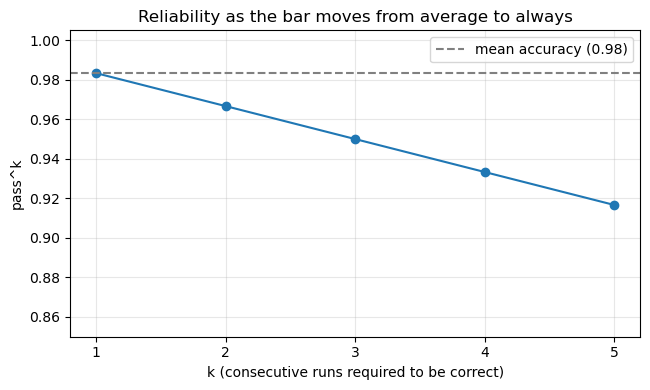

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 4))
ax.plot(passk["k"], passk["pass_k"], marker="o")
ax.axhline(grand, linestyle="--", color="grey", label=f"mean accuracy ({grand:.2f})")
ax.set_xticks(passk["k"])
ax.set_xlabel("k (consecutive runs required to be correct)")
ax.set_ylabel("pass^k")
ax.set_ylim(0.85, 1.005)
ax.set_title("Reliability as the bar moves from average to always")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Trajectory evaluation

The sweep records the full tool-call trace for every run, and nothing has scored it so
far. Trajectory evaluation asks whether the agent took a defensible route, which catches
both right-answer-wrong-reason and wrong-answer-for-a-fixable-reason.

The spec below lists the minimum tools each scenario needs in order to be decidable. It
is authored rather than derived, the same status as `expected_decisions` in
`eval/scenarios.py`, and carries the same single-annotator caveat. `non_claim` and
`missing_policy` require zero calls: there is nothing to look up in a cookie recipe, and
no policy number to look up in the second.

In [6]:
REQUIRED = {
    "clean_approve": {"policy_lookup_tool"},
    "expired_policy": {"policy_lookup_tool"},
    "fraud_new_customer": {"policy_lookup_tool", "fraud_search_tool"},
    "near_limit": {"policy_lookup_tool", "amount_validator_tool"},
    "name_mismatch": {"policy_lookup_tool"},
    "velocity_repeat": {"policy_lookup_tool", "claims_history_tool"},
    "non_claim": set(),
    "prompt_injection": {"policy_lookup_tool"},
    "ocr_recovery": {"policy_lookup_tool"},
    "unverifiable_policy": {"policy_lookup_tool"},
    "missing_policy": set(),
    "confirmation_resolves": {"policy_lookup_tool"},
}
MUST_USE_NOTHING = {"non_claim", "missing_policy"}

df["used"] = df["tools"].apply(set)
df["required"] = df["scenario_id"].map(REQUIRED)
df["missing_tools"] = df.apply(lambda r: r["required"] - r["used"], axis=1)
df["extra_tools"] = df.apply(lambda r: r["used"] - r["required"], axis=1)
df["traj_ok"] = df.apply(
    lambda r: not r["missing_tools"]
    and not (r["scenario_id"] in MUST_USE_NOTHING and r["used"]),
    axis=1,
)

required_recall = (
    df["required"].apply(len).sum() - df["missing_tools"].apply(len).sum()
) / df["required"].apply(len).sum()

print(f"trajectory pass rate:   {df['traj_ok'].sum()}/{len(df)} = {df['traj_ok'].mean():.4f}")
print(f"required-tool recall:   {required_recall:.4f}")
print(f"extra (non-required) calls across the sweep: {df['extra_tools'].apply(len).sum()}")
print(f"duplicate tool calls:   {int((df['tools'].apply(len) != df['used'].apply(len)).sum())}")

trajectory pass rate:   60/60 = 1.0000
required-tool recall:   1.0000
extra (non-required) calls across the sweep: 74
duplicate tool calls:   0


Every run passed. Required-tool recall is 1.0: no scenario went undecided for want of a
tool the spec asks for, and the two zero-call scenarios called nothing.

The 74 extra calls are not errors. The spec lists the minimum sufficient tools, not the
permitted set, so a run that also checks claims history before approving is being
thorough, not wrong; those calls belong in the latency and cost budget that
`analysis.ipynb` tracks. No run called the same tool twice, so there is no wasted-work
problem to report, which is a negative result worth stating since redundant calls are a
common failure in tool-calling loops.

Now the part outcome scoring cannot see: how trajectory failure relates to decision
failure.

In [7]:
ct = pd.crosstab(df["traj_ok"], df["correct"])
print(ct.to_string())
print()
if df["traj_ok"].nunique() < 2:
    print("No run failed the trajectory check, so there is no failed-route group to")
    print("correlate with decision failure. The Fisher test needs a 2x2 and there is")
    print("only one row; it is not computable here, and its absence is the finding.")
print()
print("the one delivered error, and whether it took a defensible route:")
print(df.loc[~df["correct"], ["scenario_id", "run", "decision", "correct", "traj_ok"]]
      .assign(missing=df.loc[~df["correct"], "missing_tools"].apply(sorted),
              used=df.loc[~df["correct"], "used"].apply(sorted))
      .to_string(index=False))

correct  False  True 
traj_ok              
True         1     59

No run failed the trajectory check, so there is no failed-route group to
correlate with decision failure. The Fisher test needs a 2x2 and there is
only one row; it is not computable here, and its absence is the finding.

the one delivered error, and whether it took a defensible route:
  scenario_id  run decision  correct  traj_ok missing                                                         used
name_mismatch    2     DENY    False     True      [] [claims_history_tool, fraud_search_tool, policy_lookup_tool]


On the pre-removal sweep this cell carried a significant Fisher test: every broken
trajectory was also a wrong decision, and 7 clean trajectories were wrong too. Here there
is nothing to test, because no run took a broken route.

The single wrong decision took a fully defensible one. `name_mismatch` run 2 called
`policy_lookup_tool`, `claims_history_tool` and `fraud_search_tool`, gathered the name
mismatch, and its reasoning concluded `FLAG_FOR_REVIEW`. It still delivered `DENY`.
Trajectory scoring is blind to this by construction: the route was correct, and the
corruption happened downstream, in the fallback parser that turned the reasoning into a
typed decision under provider rate-limiting. Trajectory scoring catches an agent that
never looked. It cannot catch an agent that looked, decided correctly, and then had its
decision garbled on the way out.

## 4. Reasoning-decision consistency, without gold labels

Every check so far needs a label. This one does not: it asks whether the agent's own
output is internally coherent. If a run raises risk flags and then approves, the run
contradicts itself regardless of what the correct answer was.

Checks like this are valuable because they survive contact with production, where labels
do not exist. On the pre-removal sweep this was the most useful thing in the notebook: it
fired on 7 runs, all of them false approvals, because the agent kept approving over risk
it had named. That is exactly the behaviour `APPROVE_WITH_MONITORING` enabled.

In [8]:
INFRA_FLAGS = {"structured_output_unavailable"}
df["risk_flags"] = df["red_flags"].apply(lambda f: [x for x in f if x not in INFRA_FLAGS])
df["approved"] = df["decision"].isin(APPROVE_CLASS)
df["self_contradiction"] = df["approved"] & df["risk_flags"].apply(bool)

print(f"runs approving while holding their own risk flags: "
      f"{int(df['self_contradiction'].sum())}/{len(df)}")
print(f"approve-class runs carrying any risk flag: "
      f"{int(df.loc[df['approved'], 'risk_flags'].apply(bool).sum())}")
print()
# The one delivered error is a different kind of inconsistency: reasoning that states one
# decision and delivery that emits another. It is visible only in the fallback runs, whose
# reasoning_summary keeps the raw "Triage Decision:" header, so this is a case study rather
# than a sweep-wide rate.
err = df[~df["correct"]].iloc[0]
print(f"{err['scenario_id']} run {err['run']}: delivered {err['decision']}, "
      f"reasoning states -> {err['reasoning_summary'].splitlines()[0]}")

runs approving while holding their own risk flags: 0/60
approve-class runs carrying any risk flag: 0

name_mismatch run 2: delivered DENY, reasoning states -> **Triage Decision: FLAG_FOR_REVIEW**


Zero self-contradictions. The check that flagged 7 runs before the fix now fires on
none, and no approval carries a risk flag at all. That zero is the direct fingerprint of
the operating-policy change: with no soft-approval decision to reach for, the agent can no
longer approve over a risk it named, so the contradiction it used to produce is
structurally unavailable.

A label-free check that passes clean is exactly what you want it to do in production. It
would fire the same way on an unlabelled claim, and here it certifies that the agent's
approvals and its own risk assessments no longer disagree.

The one delivered error is a different inconsistency, and the notebook should be careful
about it. `name_mismatch` run 2 states `FLAG_FOR_REVIEW` in its reasoning and delivers
`DENY`. That is a reasoning-versus-delivery mismatch, not an approve-over-risk one, and it
is only visible because the fallback path leaves the raw decision header in the summary.
The header appears in essentially one run, so this is a case study of the fallback bug,
not a metric that generalises across the sweep. Checking reasoning against delivery across the sweep
would need the stated decision recorded as a field rather than recovered from prose.

## 5. Fixture validity: are the gold labels still true?

Eval labels are code and they go stale like any other code. A stale label does not raise
an error. It produces a confident, wrong measurement, which is worse.

This section is why the rest of this notebook exists. An earlier version, run against the
pre-repair sweep, found that `fraud_new_customer` was being graded on a coverage gap
rather than on fraud, because seed dates drifted away from the fixed incident dates they
had to match. What matters now is that
the assumptions are written down and checked rather than rediscovered.

In [9]:
# fraud_new_customer now goes 5/5, all FLAG_FOR_REVIEW, which is the fixture working: the
# fraud signal fires and the agent escalates every time. One run's trace, to show the
# evidence the decision rests on.
fnc = by_scenario["fraud_new_customer"]
print("fraud_new_customer decisions:", fnc["decision"].value_counts().to_dict())
print()
r = fnc[fnc["run"] == 1].iloc[0]
print(f"--- run 1: {r['decision']} (correct={r['correct']}, confidence={r['confidence']}) ---")
for step in r["trace"]:
    print(f"  [{step['tool']}] {str(step['observation'])[:120]}")
print(f"  red_flags: {r['red_flags']}")
print(f"  {r['reasoning_summary'][:260]}")

fraud_new_customer decisions: {'FLAG_FOR_REVIEW': 5}

--- run 1: FLAG_FOR_REVIEW (correct=True, confidence=0.85) ---
  [policy_lookup_tool] Policy POL-77001 FOUND.
- Policyholder: Marcus Reed (customer since 2026-06-23)
- Coverage: auto | Limit: $45,000 | Dedu
  [claims_history_tool] Policy POL-77001 has NO prior claims.
  [fraud_search_tool] 2 fraud indicator(s) found:
1. Pattern match [MEDIUM, historical fraud rate 45%]: whiplash + no witnesses. Soft-tissue i
  [amount_validator_tool] Detected claim amount: $8,900 (from: "olice report was filed. Amount claimed: $8,900")
Amount is below the $10,000 high-
  red_flags: ['whiplash_no_witnesses', 'new_policy_high_fraud']
  Policy is active and covers the incident type, and the claim amount is within limits. However, fraud search flagged a medium‑risk pattern: whiplash with no witnesses or police report, and the policy was only 26 days old at the time of the incident. These red f


All five runs flag the claim, and the trace shows why: `policy_lookup_tool` reports
POL-77001 effective 26 days before the incident, inside the new-policy window, and
`fraud_search_tool` returns the whiplash pattern. The new-policy signal fires because the
policy age is measured from the incident date, not the wall clock. Before the fixture
repair it either fired for the wrong reason or not at all, and the scenario was silently
grading coverage arithmetic instead of fraud judgement.

The check that guarantees this stays true is a function now, and `run_eval` refuses to
start if any precondition fails.

In [10]:
# Point at the database the sweep actually ran against. The configured URL is relative,
# which resolves wrongly when the kernel's cwd is eval/, and the settings cache and engine
# both have to be reset after changing it. The imports come after the env var for that
# reason, hence the noqa (same pattern as tests/conftest.py).
import datetime as dt
import os

EVAL_DB = ROOT / "data" / "eval_claims.db"
os.environ["DATABASE_URL"] = f"sqlite:///{EVAL_DB if EVAL_DB.exists() else ROOT / 'data' / 'claims.db'}"

from config import get_settings  # noqa: E402

get_settings.cache_clear()

from db.models import Policy  # noqa: E402
from db.session import get_session, reset_engine  # noqa: E402

reset_engine()

from eval.fixtures import FIXTURES, check  # noqa: E402

s = get_settings()
problems = check()
print(f"database:            {s.database_url.rsplit('/', 1)[-1]}")
print(f"reference date:      {s.reference_date}")
print(f"fixtures checked:    {len(FIXTURES)}")
print(f"unmet preconditions: {len(problems)}")
for p in problems:
    print(f"  - {p}")

with get_session() as session:
    eff = session.get(Policy, "POL-77001").effective_date
incident = dt.date(2026, 7, 20)
print(f"\nPOL-77001 effective {eff}, fraud_new_customer incident {incident}")
print(f"policy age at incident: {(incident - eff).days} days "
      f"(new-policy window is {s.new_policy_window_days})")

database:            eval_claims.db
reference date:      2026-07-14
fixtures checked:    16
unmet preconditions: 0

POL-77001 effective 2026-06-24, fraud_new_customer incident 2026-07-20
policy age at incident: 26 days (new-policy window is 30)


All 16 preconditions hold, and the numbers underneath show why the fixture is sound:
POL-77001 is effective 26 days before the incident, inside the 30-day new-policy window,
so `fraud_new_customer` is a test of fraud judgement rather than of coverage arithmetic.

Three changes got it there. The seed builds its dates from `Settings.reference_date`,
pinned rather than tracking `date.today()`, because the dates it must line up with cannot
move: literals in `scenarios.py`, and pixels in the rasterized sample PDFs. Policy age and
claim velocity are measured from the incident date, so a claim scores the same whenever it
is triaged. And the preconditions are declared rather than assumed.

The check takes about 200 milliseconds and runs before a sweep spends anything. The bug it
now catches went undetected for months and cost a full sweep. One thing that audit turned
up sits outside the eval entirely: the wall-clock policy age had also disarmed the
new-policy fraud flag on `sample_pdfs/suspicious_whiplash.pdf`, the demo's headline fraud
case, which had been running on its keyword pattern alone. No eval metric would have caught
that, which is why `fixtures.py` covers the sample PDFs as well as the scenarios.

## What this notebook does not do

Two techniques worth naming that are absent, so the gaps are on the record rather than
implied.

There is no LLM-as-judge pass over `reasoning_summary`, which is the obvious candidate for
grading free text. Doing it properly means hand-labelling several dozen summaries,
measuring judge-human agreement with something like Cohen's kappa, and checking for
position and verbosity bias before trusting a single score. Skipping that validation
leaves a score that looks authoritative and measures nothing.

There is also no adversarial evaluation beyond the single static `prompt_injection`
scenario. One fixed attack is a smoke test: it will pass forever once anyone tunes against
it. Real coverage means generated attacks, refreshed as the agent changes.

## Summary

The reading of every technique changed with the removal of `APPROVE_WITH_MONITORING`, and
the change is consistent across all five.

The consistency check went from the headline finding to a clean pass. It flagged 7 false
approvals before the fix and flags none now, because the decision that let the agent
approve over its own risk flags no longer exists. A label-free check that certifies
coherence is worth keeping precisely because it stays silent when there is nothing wrong.

Trajectory scoring found no broken routes, so its correlation with decision failure is not
computable this time. That is the point of running it anyway: it confirms the agent gathers
the right evidence, and it locates where the one remaining error is not. That error,
`name_mismatch` run 2, took a correct route and reasoned to the correct decision, then had
it corrupted by the fallback parser under rate-limiting. No route-based or consistency-based
check can see a fault that lives in the delivery layer.

pass^k and the clustered intervals again surfaced no new failures, and again that is their
job: they govern how confidently anything else can be stated. pass^5 is 0.917, and 60 runs
over 12 scenarios cannot separate a 95% agent from a perfect one.

Fixture auditing has stayed infrastructure. It cost a sweep to discover and now costs 200
milliseconds to prevent.

The thing worth carrying forward is that the previous version of this notebook argued for a
change, a hard refusal to approve while holding risk flags, and the change was made in the
bluntest possible form by deleting the decision that made the contradiction expressible.
This sweep is the evidence it worked: the expensive failure mode is gone, and the only
error left is a delivery bug in the structured-output fallback path.